In [ ]:
import json

# Inisiasi data latih dan data validasi
plain_training_data_path = "Datasets/plain-train.json"
plain_validation_data_path = "Datasets/plain-val.json"
cipher_training_data_path = "Datasets/cipher-train.json"
cipher_validation_data_path = "Datasets/cipher-val.json"

def read_files(path):
    with open(path, "r", encoding="utf-8") as f:
        data_train_dataset = json.load(f)
    return data_train_dataset

plain_training_data = read_files(plain_training_data_path)
plain_validation_data = read_files(plain_validation_data_path)
cipher_training_data = read_files(cipher_training_data_path)
cipher_validation_data = read_files(cipher_validation_data_path)

max_length = 12 # Panjang maksimum satu data
train_dataset = [[cipher_sentence, plain_sentence] for cipher_sentence, plain_sentence in zip(cipher_training_data, plain_training_data) if len(cipher_sentence) <= max_length and len(plain_sentence) <= max_length]
val_dataset = [[cipher_sentence, plain_sentence] for cipher_sentence, plain_sentence in zip(cipher_validation_data, plain_validation_data) if len(cipher_sentence) <= max_length and len(plain_sentence) <= max_length]
cipher_training_data, plain_training_data = zip(*train_dataset)
cipher_validation_data, plain_validation_data = zip(*val_dataset)

print(len(cipher_training_data))
print(len(cipher_validation_data))
print(cipher_training_data[3745:3750])
print(plain_training_data[3745:3750])

3750
1250
('45i8mv5E4', 'Z2MWCfpa', 'b8cAc0Y3', 'vMgQioKVOi', '3VN9vlINHb1')
('stewart20', 'freckles', 'kirkland', 'littlegirl', 'tracybeaker')


In [ ]:
from customtokenizer import CustomTokenizer

# prepare Cipher tokenizer, this is the input
tokenizer = CustomTokenizer(char_level=True, lower=False)
tokenizer.fit_on_texts(cipher_training_data)
tokenizer.save("c_tokenizer.json")

# prepare Plain tokenizer, this is the output
detokenizer = CustomTokenizer(char_level=True, lower=False)
detokenizer.fit_on_texts(plain_training_data)
detokenizer.save("p_tokenizer.json")

Fitting tokenizer: 100%|██████████| 3750/3750 [00:00<00:00, 896474.21it/s]


In [ ]:
pip install mltu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 126.8 MB/s eta 0:00:00
  Created wheel for qqdm: filename=qqdm-0.0.7-py3-none-any.whl size=6467 sha256=4a208efb2e3ad63cab7f255f6bce4b83c47bc6031ce6680e342f0cacc0ed1d11
  Stored in directory: /root/.cache/pip/wheels/c7/aa/d6/32e14a8d95f02429149a6f120c58c5dfc62054edd4e8c49ddc
Successfully built qqdm


In [ ]:
import tensorflow as tf
from mltu.tensorflow.dataProvider import DataProvider
import numpy as np

def preprocess_inputs(data_batch, label_batch):
    encoder_input = np.zeros((len(data_batch), tokenizer.max_length)).astype(np.int64)
    decoder_input = np.zeros((len(label_batch), detokenizer.max_length)).astype(np.int64)
    decoder_output = np.zeros((len(label_batch), detokenizer.max_length)).astype(np.int64)

    data_batch_tokens = tokenizer.texts_to_sequences(data_batch)
    label_batch_tokens = detokenizer.texts_to_sequences(label_batch)

    for index, (data, label) in enumerate(zip(data_batch_tokens, label_batch_tokens)):
        encoder_input[index][:len(data)] = data
        decoder_input[index][:len(label)-1] = label[:-1] # Drop the [END] tokens
        decoder_output[index][:len(label)-1] = label[1:] # Drop the [START] tokens

    return (encoder_input, decoder_input), decoder_output

train_dataProvider = DataProvider(
    train_dataset,
    batch_size=4,
    batch_postprocessors=[preprocess_inputs],
    use_cache=True
    )

val_dataProvider = DataProvider(
    val_dataset,
    batch_size=4,
    batch_postprocessors=[preprocess_inputs],
    use_cache=True
    )

INFO:DataProvider:Skipping Dataset validation...
INFO:DataProvider:Skipping Dataset validation...


In [ ]:
import tensorflow as tf
from encoder import Encoder
from decoder import Decoder

def Transformer(
    input_vocab_size: int,
    target_vocab_size: int,
    encoder_input_size: int = None,
    decoder_input_size: int = None,
    num_layers: int=6,
    d_model: int=512,
    num_heads: int=8,
    dff: int=2048,
    dropout_rate: float=0.1,
    ) -> tf.keras.Model:
    """
    A custom TensorFlow model that implements the Transformer architecture.

    Args:
        input_vocab_size (int): The size of the input vocabulary.
        target_vocab_size (int): The size of the target vocabulary.
        encoder_input_size (int): The size of the encoder input sequence.
        decoder_input_size (int): The size of the decoder input sequence.
        num_layers (int): The number of layers in the encoder and decoder.
        d_model (int): The dimensionality of the model.
        num_heads (int): The number of heads in the multi-head attention layer.
        dff (int): The dimensionality of the feed-forward layer.
        dropout_rate (float): The dropout rate.

    Returns:
        A TensorFlow Keras model.
    """
    inputs = [
        tf.keras.layers.Input(shape=(encoder_input_size,), dtype=tf.int64),
        tf.keras.layers.Input(shape=(decoder_input_size,), dtype=tf.int64)
        ]

    encoder_input, decoder_input = inputs

    encoder = Encoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads, dff=dff, vocab_size=input_vocab_size, dropout_rate=dropout_rate)(encoder_input)
    decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads, dff=dff, vocab_size=target_vocab_size, dropout_rate=dropout_rate)(decoder_input, encoder)

    output = tf.keras.layers.Dense(target_vocab_size)(decoder)

    return tf.keras.Model(inputs=inputs, outputs=output)

In [ ]:
# Hyperparameter dapat diubah sesuai kebutuhan
transformer = Transformer(
    num_layers=2,
    d_model=128,
    num_heads=2,
    dff=512,
    input_vocab_size=len(tokenizer)+1,
    target_vocab_size=len(detokenizer)+1,
    dropout_rate=0.1,
    encoder_input_size=tokenizer.max_length,
    decoder_input_size=detokenizer.max_length
    )

transformer.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (Encoder)   │ (None, 14, 128)   │    536,832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (Decoder)   │ (None, 14, 128)   │    801,280 │ input_layer_1[0]… │
│                     │                   │            │ encoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 14, 66)    │      8,514 │ decoder[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,346,626 (5.14 MB)

 Trainable params: 1,346,626 (5.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam
from mltu.tensorflow.transformer.utils import MaskedAccuracy, MaskedLoss

optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

# Compile the model
transformer.compile(optimizer=optimizer,
                    loss= MaskedLoss,
                    metrics=[MaskedAccuracy],
                    run_eagerly=False)

In [ ]:
from datetime import datetime
from packaging import version
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

start_time = time.time()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = transformer.fit(
    train_dataProvider,
    epochs=100,
    validation_data=val_dataProvider,
    callbacks=[early_stop]
    )

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - loss: 2.7346 - masked_accuracy: 0.2418 - val_loss: 2.4212 - val_masked_accuracy: 0.2857
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 2.3991 - masked_accuracy: 0.2892 - val_loss: 2.2751 - val_masked_accuracy: 0.3139
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 2.2839 - masked_accuracy: 0.3148 - val_loss: 2.1811 - val_masked_accuracy: 0.3446
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 2.1534 - masked_accuracy: 0.3598 - val_loss: 2.0209 - val_masked_accuracy: 0.4003
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 2.0123 - masked_accuracy: 0.4022 - val_loss: 1.8790 - val_masked_accuracy: 0.4407
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.9115 - masked_accuracy: 0.4294 - val_loss: 1.8169 - val_masked_accuracy: 0.4615
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 1.8403 - masked_accuracy: 0.4495 - val_loss: 1.7773 - val_masked_accuracy: 0.4690
Epoch 

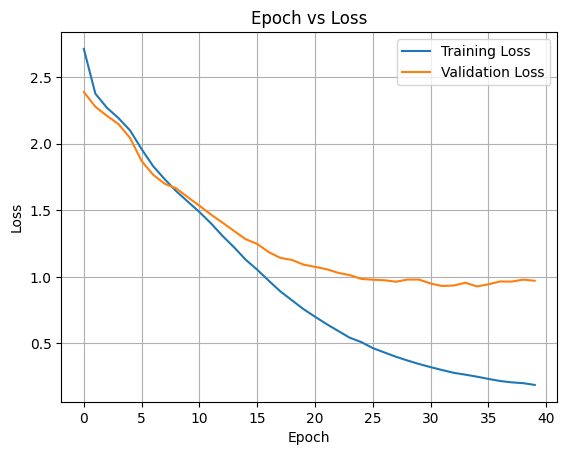

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.grid(True)
plt.show()
# Menyimpan gambar
plt.savefig("Loss layer 2 head 2.png")

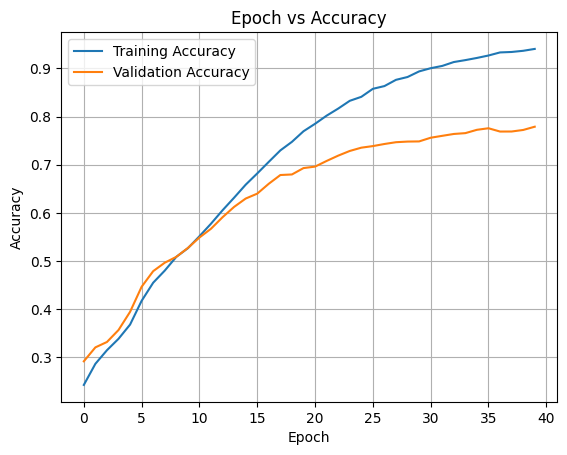

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['masked_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_masked_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Epoch vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()
# Menyimpan gambar
plt.savefig("Akurasi layer 2 head 2.png")

In [ ]:
# Inisiasi data untuk proses uji model
plain_test_data_path = "Datasets/plain-test.json"
cipher_test_data_path = "Datasets/cipher-test.json"

plain_test_data = read_files(plain_test_data_path)
cipher_test_data = read_files(cipher_test_data_path)

max_length = 12 # Panjang maksimum satu data
test_dataset = [[cipher_sentence, plain_sentence] for cipher_sentence, plain_sentence in zip(cipher_test_data, plain_test_data) if len(cipher_sentence) <= max_length and len(plain_sentence) <= max_length]
cipher_test_data, plain_test_data = zip(*test_dataset)

print(len(cipher_test_data))
print(len(plain_test_data))
print(cipher_test_data)
print(plain_test_data)

1000
1000
('pNHYeEYo', 'nsMl6U3Wh', 'e0xf4qazn', '13mymzq3e', 'SHT6YJPOVI', 'X6Dl0bIU', 'sROmRJcN', 'w87CDu7D27', 'snrgQdxy', 'YwQm2Vpbb', 'P3vfvczMv', 'ZtqhadriT', 'kKTvtSPl', 'sBLgIDo92', 'z4iQn847i', 'ZIe0e1fB', 'OT4bIvKf', 'uzo06p2x3m5', 'OZORPcdm', 'II3cWwGV', 'TscwY0J2', 'dmDkJqFP', 'uuuuuuuu', 'PIfKSTcVO', 'qw11wv8i5', 'Cy728BKQ', 'OLYTPWno', 'PcwVUkTkD', 'kFM5koP9', 'kRGs0OCmk', 'aLafdTNL', 'M9LvWwY9f', 'TEZBUKO4', 'JunfO23S', 'zLEgPAzL', 'CDuBDBy4', 'IPsISoTl', 'v1ItPm7k', 'd33fuS4DyR', 'LAW0Y0aC', 'dfaPcUfYTZc', 'D1EBCxuI', 'k7f6cEg4', 'jGf8iHPB', 'DLQLEBII', 'oKTyqcQu', 'XZYLXZfc', '7KEoiba8', 'Wx9nwX6vf', 'dzHBLDL9j', 'Y0cBVOlR', '58Fyu70y5', 'f9hyyFfN', 'v0vsqxqmq0', 'PELLQFKD', 'WPMcZYULXPd', 'Z4P3LJjL', 'tSfBXxKRI', 'SInXQqGT', 'wSgEb1SSa', 'dpVhAhra', 'bJQznYNM3', '9kzXXwsu', 'fFnysBfP', 'duuTu2Ut', 'u2j8fztC', 'ZtakblkaT', 'nMWPddPO', 'zwztwm3w3', 'II3GZsTI', 'B3Yqyqiv0', 'smvpqrum', 'CylZQuvrhr', 'XPXZZNSZL', 'XZYdPccLe', 'DstQTBlkRq', 'nEa9b1fo', 'dmDkEc3ytQ', 'h05W3

In [ ]:
test_dataProvider = DataProvider(
    test_dataset,
    batch_size=4,
    batch_postprocessors=[preprocess_inputs],
    use_cache=True
    )

INFO:DataProvider:Skipping Dataset validation...


In [ ]:
loss, accuracy = transformer.evaluate(test_dataProvider)
print(loss)
print(accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.9405 - masked_accuracy: 0.7744
0.9404565691947937
0.7743807435035706


In [ ]:
import json
import numpy as np

# Load file json
with open('p_tokenizer.json', 'r') as f:
    tokenizer_config = json.load(f)

# The actual character-to-ID mapping is within 'index_word'
char_to_id_mapping = tokenizer_config['index_word']

# Penting: Balik dictionary-nya supaya kita bisa cari Karakter berdasarkan ID
# Kita paksa i jadi int karena kadang JSON ngebaca key sebagai string
id_to_char = {int(i): char for i, char in char_to_id_mapping.items()}

In [ ]:
# Ambil satu batch (misal batch pertama)
# Structure: ((encoder_input, decoder_input), decoder_output)
(batch_inputs, batch_targets) = test_dataProvider[0]

# Lakukan prediksi
predictions = transformer.predict(batch_inputs)

# Ambil index dengan probabilitas tertinggi di setiap posisi karakter
predicted_indices = np.argmax(predictions, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [ ]:
def decode_to_text(indices, mapping):
    # Gabungkan karakter, abaikan index 0 (biasanya padding)
    return "".join([mapping.get(idx, "") for idx in indices if idx != 0])

# Coba tampilkan hasil untuk beberapa data dalam satu batch
for i in range(len(predicted_indices)):
    hasil_prediksi = decode_to_text(predicted_indices[i], id_to_char)
    label_asli = decode_to_text(batch_targets[i], id_to_char)

    print(f"Data ke-{i+1}:")
    print(f"  > Prediksi: {hasil_prediksi}")
    print(f"  > Asli    : {label_asli}")
    print("-" * 20)

Data ke-1:
  > Prediksi: hoodtrile1<eos><eos><eos><eos>
  > Asli    : ghostrider<eos>
--------------------
Data ke-2:
  > Prediksi: constanta<eos><eos><eos><eos><eos>
  > Asli    : constanta<eos>
--------------------
Data ke-3:
  > Prediksi: soamorato<eos><eos><eos><eos><eos>
  > Asli    : enamorado<eos>
--------------------
Data ke-4:
  > Prediksi: 1aieojacie<eos><eos><eos><eos>
  > Asli    : laffytaffy<eos>
--------------------
